# Fundamentos de Data Science – Práctica para el Examen

**Preparacion del entorno**
Primero debemos preparar el entorno de trabajo con Pandas

**Cargar los datos**
Se utilizo un dateset enviado por el profesor.

In [1]:
import pandas as pd
import numpy as np

URL = 'https://raw.githubusercontent.com/krishnaik06/playstore-Dataset/main/googleplaystore.csv'
df = pd.read_csv(URL)

**Exploracion inicial de los datos**
En esta parte comenzamos a revisar y explorar la informacion del DataFrame utilizando las operaciones basicas como Head, Tail, Info, Describe y Types.

Con Head y Tail podemos visualizar las primeras y ultimas filas respectivamente.

Con Info entrega un resumen conciso del DataFrame.

Con Describe "genera estadisticas descriptivas que resumen la tendencia central, dispersion y forma de la distribucion de un conjunto de datos".

Con Types nos permite saber los tipos de datos de cada columna.

In [2]:
print("Primeras filas del DataFrame:")
print(df.head(10))

print("Ultimas filas del DataFrame:")
print(df.tail(5))

print("Informacion del DataFrame:")
print(df.info())

print("Estadisticas descriptivas del DataFrame:")
print(df.describe().round(2))

print("Tipos originales:")
print(df.dtypes)

Primeras filas del DataFrame:
                                                 App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                                Coloring book moana  ART_AND_DESIGN     3.9   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN     4.7   
3                              Sketch - Draw & Paint  ART_AND_DESIGN     4.5   
4              Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN     4.3   
5                         Paper flowers instructions  ART_AND_DESIGN     4.4   
6            Smoke Effect Photo Maker - Smoke Editor  ART_AND_DESIGN     3.8   
7                                   Infinite Painter  ART_AND_DESIGN     4.1   
8                               Garden Coloring Book  ART_AND_DESIGN     4.4   
9                      Kids Paint Free - Drawing Fun  ART_AND_DESIGN     4.7   

  Reviews  Size     Installs  Type Price Content Rating  \
0     159   19M      10,000+  

**Limpieza de datos**
En este punto revisamos los tipos de datos de cada columna, si tenemos datos nulos y/o duplicados

Para el DataFrame seleccionado revisamos lo siguiente:

Primero, se confirma si tenemos datos nulos en este caso encontramos 1487 datos nulos lo que corresponde al 13,7% de la informacion, la columna con mas datos nulos es Rating (1474) y al revisarla  corresponde a la evaluacion que le entregan a las apps, por lo tanto se considera que la mejor opcion es mantener los Nan como nulos ya que es una variable numerica y reemplazarlo por texto podria alterar el tipo de dato y eso dificultaria el analisis, ademas se considera que la ausencia de calificacion puede interpretarse como informacion valida en el contexto de este dataset.
Con respecto a los 13 datos restantes nulos se realiza la opcion de eliminarlos ya que se considera que al ser poca la proporcion de estos respecto al total del dataset no generara mayor diferencias en el analisis final.

Segundo, se reviso si teniamos columnas duplicadas y nos indico que eran 483 por lo tanto se decidio eliminarlas para que mas adelante no se vea afectado el analisis.


In [3]:
print("Verificacion de datos nulos:")
print(df.isnull().sum())


Verificacion de datos nulos:
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64


In [4]:
df = df.dropna(subset=['Type', 'Content Rating', 'Current Ver', 'Android Ver'])

In [5]:
print("Verificacion de datos nulos:")
print(df.isnull().sum())

n_duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {n_duplicados}")

duplicados = df[df.duplicated()]
print(duplicados.head())

col_duplicados = df.duplicated(subset=['App']).sum()
print(f"Columna App duplicada: {col_duplicados}")

Verificacion de datos nulos:
App                  0
Category             0
Rating            1469
Reviews              0
Size                 0
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          0
Android Ver          0
dtype: int64
Filas duplicadas: 483
                              App  Category  Rating Reviews  \
229  Quick PDF Scanner + OCR FREE  BUSINESS     4.2   80805   
236                           Box  BUSINESS     4.2  159872   
239            Google My Business  BUSINESS     4.4   70991   
256           ZOOM Cloud Meetings  BUSINESS     4.4   31614   
261     join.me - Simple Meetings  BUSINESS     4.0    6989   

                   Size     Installs  Type Price Content Rating    Genres  \
229  Varies with device   5,000,000+  Free     0       Everyone  Business   
236  Varies with device  10,000,000+  Free     0       Everyone  Business   
239  Varies with device   5

In [6]:
df = df.drop_duplicates()
n_duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {n_duplicados}")


Filas duplicadas: 0


Tercero se revisa el tipo de datos de la columnas y nos encontramos con que tenemos las columnas Reviews, installs y price como str y estas deberian ser dato numerico. Para el caso de la colummna Size segun el diccionario de datos este dice que debe ser float y tamaño MB, por lo tanto realizaremos los cambios de tipo.

In [7]:
df['Reviews'] = pd.to_numeric(df['Reviews'])

df['Installs'] = df['Installs'].astype(str)
df['Installs'] = df['Installs'].str.replace(',', '')
df['Installs'] = df['Installs'].str.replace('+', '', regex=False)
df['Installs'] = pd.to_numeric(df['Installs'])

In [8]:
df['Price'] = df['Price'].astype(str)
df['Price'] = df['Price'].str.replace('$', '', regex=False)
df['Price'] = pd.to_numeric(df['Price'])

print(df[['Reviews', 'Installs', 'Price']].dtypes)


Reviews       int64
Installs      int64
Price       float64
dtype: object


In [9]:
print(df['Size'].unique()[:20])

df['Size'] = df['Size'].replace('Varies with device', np.nan)
df['Size'] = df['Size'].astype(str)
df['Size'] = df['Size'].str.replace('M', '', regex=False)

df['Size'] = pd.to_numeric(df['Size'], errors='coerce')

<StringArray>
[ '19M',  '14M', '8.7M',  '25M', '2.8M', '5.6M',  '29M',  '33M', '3.1M',
  '28M',  '12M',  '20M',  '21M',  '37M', '5.5M',  '17M',  '39M',  '31M',
 '4.2M', '7.0M']
Length: 20, dtype: str


In [10]:
print(df[['App', 'Size']].head())
print(df['Size'].dtype)

                                                 App  Size
0     Photo Editor & Candy Camera & Grid & ScrapBook  19.0
1                                Coloring book moana  14.0
2  U Launcher Lite – FREE Live Cool Themes, Hide ...   8.7
3                              Sketch - Draw & Paint  25.0
4              Pixel Draw - Number Art Coloring Book   2.8
float64


Cuarto, se verifica que tengamos valores unicos en la columna Category, Type y Genres para confirmar que no tenemos inconsistencias en estos valores, ademas se verifica que los valores de la columna Rating no sean mayores a 5 ni menores a 1 ya que como señala el diccionario de datos esta columna solo debe tener valores entre 1 y 5.

In [11]:
print(df['Category'].unique())

<StringArray>
[     'ART_AND_DESIGN',   'AUTO_AND_VEHICLES',              'BEAUTY',
 'BOOKS_AND_REFERENCE',            'BUSINESS',              'COMICS',
       'COMMUNICATION',              'DATING',           'EDUCATION',
       'ENTERTAINMENT',              'EVENTS',             'FINANCE',
      'FOOD_AND_DRINK',  'HEALTH_AND_FITNESS',      'HOUSE_AND_HOME',
  'LIBRARIES_AND_DEMO',           'LIFESTYLE',                'GAME',
              'FAMILY',             'MEDICAL',              'SOCIAL',
            'SHOPPING',         'PHOTOGRAPHY',              'SPORTS',
    'TRAVEL_AND_LOCAL',               'TOOLS',     'PERSONALIZATION',
        'PRODUCTIVITY',           'PARENTING',             'WEATHER',
       'VIDEO_PLAYERS',  'NEWS_AND_MAGAZINES', 'MAPS_AND_NAVIGATION']
Length: 33, dtype: str


In [12]:
print(df['Type'].unique())

print(df['Genres'].unique())

<StringArray>
['Free', 'Paid']
Length: 2, dtype: str
<StringArray>
[                   'Art & Design',       'Art & Design;Pretend Play',
         'Art & Design;Creativity', 'Art & Design;Action & Adventure',
                 'Auto & Vehicles',                          'Beauty',
               'Books & Reference',                        'Business',
                          'Comics',               'Comics;Creativity',
 ...
             'Lifestyle;Education',    'Books & Reference;Creativity',
     'Books & Reference;Education',                'Puzzle;Education',
          'Role Playing;Education',        'Role Playing;Brain Games',
              'Strategy;Education',             'Racing;Pretend Play',
        'Communication;Creativity',             'Strategy;Creativity']
Length: 119, dtype: str


In [13]:
df[df['Rating'] > 5]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [14]:
df[df['Rating'] < 1]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


# Graficos

**Visualizaciones exploratorias univariantes**

**Grafico 1**

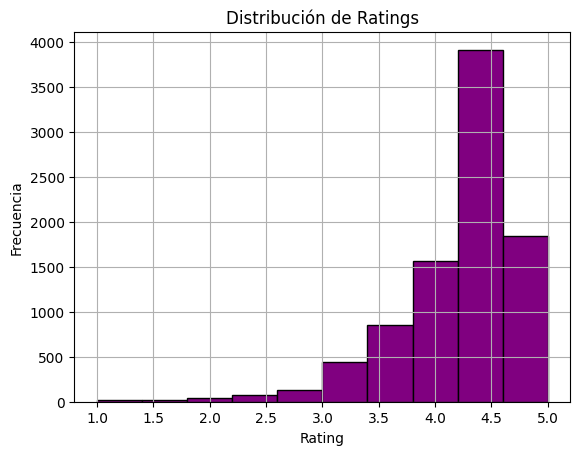

In [15]:
import matplotlib.pyplot as plt

df['Rating'].hist(color='purple', edgecolor='black')
plt.title('Distribución de Ratings')
plt.xlabel('Rating')
plt.ylabel('Frecuencia')

plt.show()

Para el grafico 1 se decide hacer un histograma de la calificacion de aca app y con este grafico podemos notar que la mayoria de las calificiaciones son entre 4 y 4.5.

**Grafico 2**

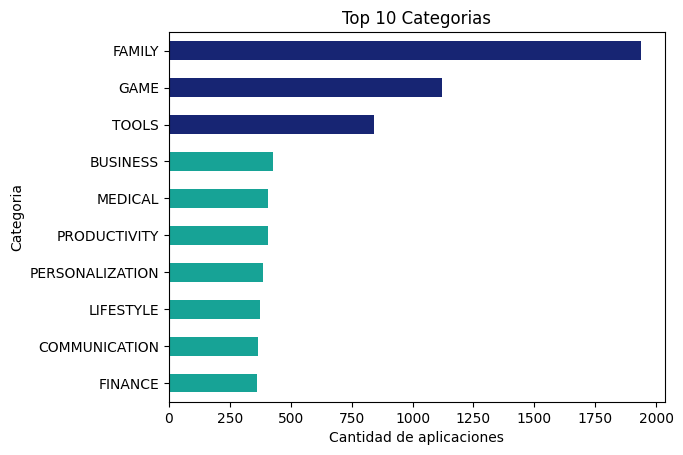

In [16]:
colores = ['#172573', '#172573', '#172573', '#17A396', '#17A396', '#17A396', '#17A396', '#17A396', '#17A396', '#17A396']

df['Category'].value_counts().head(10).plot(kind='barh', color=colores)
plt.title('Top 10 Categorias')
plt.xlabel('Cantidad de aplicaciones')
plt.ylabel('Categoria')
plt.gca().invert_yaxis()
plt.show()

Para el grafico 2 se decide realizar un grafico de barras con un top 10 de las categorias, aca podemos ver que la categoria familia es la que tiene mas aplicaciones.

**Visualizaciones exploratorias multivariantes**

**Grafico 3**

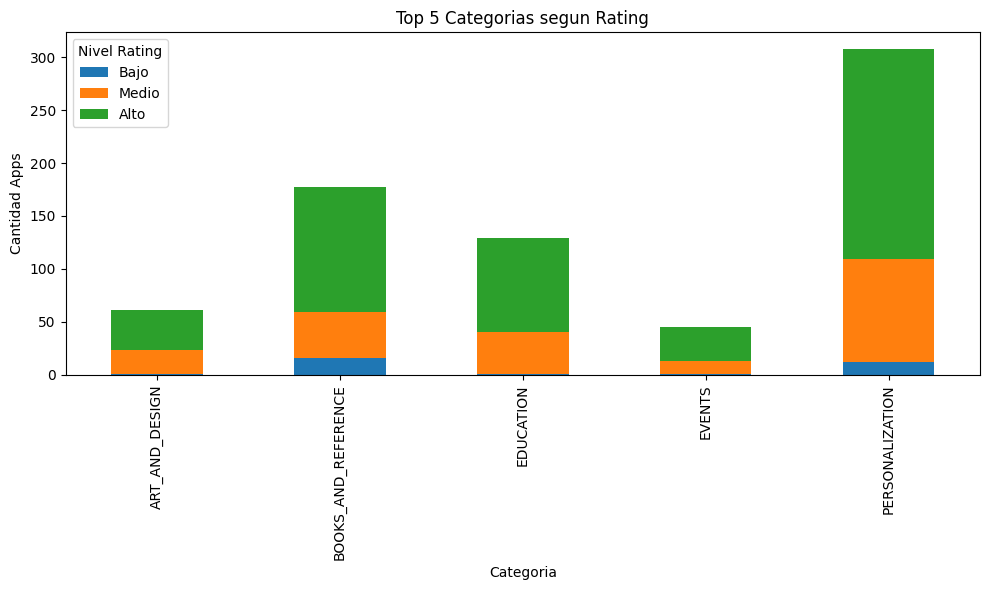

In [22]:
top5 = (df.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(5).index)

df_top = df[df['Category'].isin(top5)]

df_top['Rating_Level'] = pd.cut(df_top['Rating'], bins=[0, 3.5, 4.2, 5], labels=['Bajo', 'Medio', 'Alto'])

tabla = pd.crosstab(df_top['Category'], df_top['Rating_Level'])

tabla.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Top 5 Categorias segun Rating')
plt.xlabel('Categoria')
plt.ylabel('Cantidad Apps')
plt.legend(title='Nivel Rating')
plt.tight_layout()
plt.show()

En el grafico 3 se muestran las 5 categorias de aplicaciones con mejor promedio de calificacion, cada barra representa la cantidad de aplicaciones calificadas segun su nivel de valoracion: bajo, medio y alto. Podemos observar que la mayoria de las plicadion dentreo de estas categorias se concentran en un nivel de rating "Alto", esto nos permite sugerir que estas categorias mantienen mejores estandares de calidad o experiencia de usuario.

**Grafico 4**

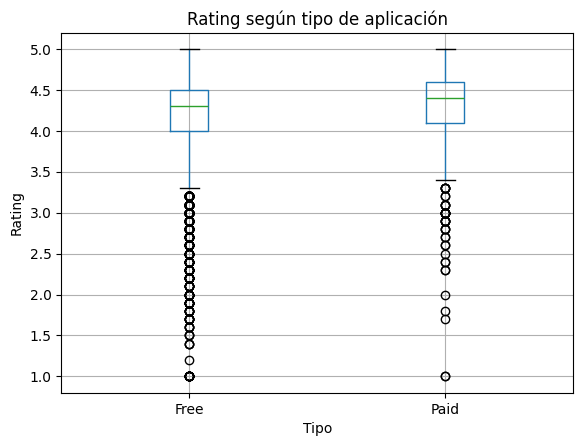

In [18]:
df.boxplot(column='Rating', by='Type')
plt.title('Rating según tipo de aplicación')
plt.suptitle('')
plt.xlabel('Tipo')
plt.ylabel('Rating')
plt.show()


Para el grafico 4 se realizo una comparacion entre el rating y si la aplicacion es gratis o pagada y podemos observar que las aplicaciones pagas tiene una mejor evaluacion que las gratis.